# Capstone Project: TeleConnect Data Analysis
## Introduction

Telecommunications companies generate vast amounts of customer data that can reveal critical insights about service usage, payment behavior, and satisfaction drivers. However, understanding why customers stay or leave requires more than raw data—it demands careful analysis to uncover patterns that inform retention strategies.


This project analyzes customer data from TeleConnect, a telecommunications company facing customer retention challenges. The dataset contains information about customer demographics, service subscriptions (phone, internet, streaming), contract types (month-to-month, one-year, two-year), payment methods, monthly charges, tenure, and churn status. These variables provide a comprehensive view of customer behavior and the factors that may influence their decision to remain with or leave the company.


The purpose of this project is to clean and explore the dataset, identify patterns associated with customer churn, and develop actionable insights that can guide retention efforts. The analysis aims to answer critical business questions:


*   Who are our customers (demographics)?
*   Which services drive loyalty?
*   How do contracts and payments affect retention?
*   What specific actions should we take?


The project follows a structured data analysis workflow including data inspection, data cleaning, feature engineering, exploratory data analysis (EDA), and visualization. The final stage focuses on synthesizing findings into a professional report with data-backed recommendations that TeleConnect can implement to improve customer retention and reduce churn.

## Project Objectives
The objectives of the project include:
### 1. Understand and Inspect Raw Data
Upon loading the dataset, the first step includes understanding and inspecting the raw data and inspecting its structure, datatypes and quality. The steps in this stage include:



*   Explore the structure of the dataset
*   Identify datatypes for each variable
*   Generate summary statistics
*   Identify missing values
*   Understand each variable (column)

### 2. Data Cleaning


*   Identify missing values within the dataset.
*   Identify and deal with duplicates.
*   Check for consistency in formatting of categorical data.
*   Check for consistency in output in the total_charges column, which is a product of tenure_months and monthy_charges.
*   Check for outliers using the **IQR method** and **box plots**.

### 3. Exploratory Data Analysis
Exploratory data anaysis can help identify patterns, relationships and trends within the dataset.


*   Conduct a comprehensive analysis of customer demographics.
*   Determine which services affect affect loyalty.


*   Investigate how contracts and payment methods influence retention.

### 4. Give conclusions and recommendations













## 1. Understanding the Dataset
### Section Summary

*   The dataset contains detailed information regarding customers of a
telecommuncations company, including demographics, service dubscriptions, billing information and churn status.

*   The dataset has 7043 rows and 21 columns, 17 of which contains categorical data and 3 of which have numberical data.


*   The total_charges column is the product of the tenure_months column and the monthly_charges column.


*   The dataset is particulary useful for analysing patterns and determining factors that contribute to customer churn, helping the telecom company find ways to enhance client retention.







In [53]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math


In [54]:
#Load dataset
df_connect = pd.read_csv("teleconnect_customer_data.csv")

In [55]:
#Check the first few rows (display all columns)
pd.set_option('display.max_columns', None)
df_connect.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,customer_status
0,CUST00001,Male,Yes,No,No,11,No,No phone service,DSL,No,No,No,No,Yes,Yes,One year,Yes,Bank transfer (automatic),4008.19,44090.09,Active
1,CUST00002,Female,No,Yes,No,10,Yes,Yes,DSL,No,No,Yes,Yes,No,No,Month-to-month,No,Mailed check,4409.39,44093.90,Churned
2,CUST00003,Female,No,Yes,Yes,12,Yes,No,Fiber optic,No,No,Yes,No,No,No,Two year,Yes,Credit card (automatic),4486.64,53839.68,Active
3,CUST00004,Female,No,No,No,70,Yes,No,DSL,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,4512.78,315894.60,Active
4,CUST00005,Male,Yes,No,No,36,Yes,Yes,Fiber optic,Yes,No,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),6163.53,221887.08,Churned


| column_name         | column_description                                                                                       |
|---------------------|-----------------------------------------------------------------------------------------------------------|
| customerID          | A unique ID that identifies each customer.                                                               |
| gender              | The customer's gender (Male / Female).                                                                   |
| SeniorCitizen       | Indicates if the customer is a senior citizen (1 = Yes, 0 = No).                                          |
| Partner             | Indicates if the customer has a partner (Yes / No).                                                       |
| Dependents          | Indicates if the customer has dependents (Yes / No).                                                      |
| tenure              | The number of months the customer has stayed with the company.                                           |
| PhoneService        | Indicates if the customer has phone service (Yes / No).                                                   |
| MultipleLines       | Indicates if the customer has multiple phone lines (Yes / No / No phone service).                         |
| InternetService     | The type of internet service the customer has (DSL / Fiber optic / No).                                   |
| OnlineSecurity      | Indicates if the customer has online security service (Yes / No / No internet service).                   |
| OnlineBackup        | Indicates if the customer has online backup service (Yes / No / No internet service).                     |
| DeviceProtection    | Indicates if the customer has device protection service (Yes / No / No internet service).                 |
| TechSupport         | Indicates if the customer has tech support service (Yes / No / No internet service).                      |
| StreamingTV         | Indicates if the customer has streaming TV service (Yes / No / No internet service).                      |
| StreamingMovies     | Indicates if the customer has streaming movies service (Yes / No / No internet service).                  |
| Contract            | The type of contract the customer has (Month‑to‑month / One year / Two year).                             |
| PaperlessBilling    | Indicates if the customer uses paperless billing (Yes / No).                                              |
| PaymentMethod       | The customer's payment method (Electronic check / Mailed check / Bank transfer (automatic) / Credit card (automatic)). |
| MonthlyCharges      | The amount charged to the customer monthly.                                                              |
| TotalCharges        | The total amount charged to the customer.                                                                |
| Churn               | Indicates if the customer left the company within the last month (Yes / No).                             |

In [56]:
df_connect.shape

(7043, 21)

## 2. Data Cleaning
### Section Summary
Real world data is often imperfect. it is therefore important to check and clean the data of imconsistencies to avoid biased and inaccurate conclusions upon analysis.

The data cleaning process uncovered the following:



*   There are 15No. missing values in the total_charges column. Since the column is a product of tenure_months and monthly_charges, I have filled in the missing values with the product of the values from the 2 other columns.
*   Confirmed that the values in the total_charges column are a product of tenure_months and monthly_charges.
*   The dataset does not contain duplicate values.


*   The consistency of values in the categorical variables has been confirmed.


*   **Detect Outliers**
*    Possible outliers in the total_charges variables have been identified as long-tenured, high value clients, thus they remain relevant to the analysis stage.












In [57]:
# Whoa! 21 columns! Let's get a bit more info on the dataset
df_connect.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   gender             7043 non-null   object 
 2   senior_citizen     7043 non-null   object 
 3   partner            7043 non-null   object 
 4   dependents         7043 non-null   object 
 5   tenure_months      7043 non-null   int64  
 6   phone_service      7043 non-null   object 
 7   multiple_lines     7043 non-null   object 
 8   internet_service   7043 non-null   object 
 9   online_security    7043 non-null   object 
 10  online_backup      7043 non-null   object 
 11  device_protection  7043 non-null   object 
 12  tech_support       7043 non-null   object 
 13  streaming_tv       7043 non-null   object 
 14  streaming_movies   7043 non-null   object 
 15  contract_type      7043 non-null   object 
 16  paperless_billing  7043 

In [58]:
# Check for duplicates
df_connect.duplicated().sum()

np.int64(0)

In [59]:
#Fill in the null values in total_charges by multiplying tenure with monthly_charges
df_connect["total_charges"] = df_connect["total_charges"].fillna(df_connect["tenure_months"] * df_connect["monthly_charges"])

In [60]:
df_connect.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   gender             7043 non-null   object 
 2   senior_citizen     7043 non-null   object 
 3   partner            7043 non-null   object 
 4   dependents         7043 non-null   object 
 5   tenure_months      7043 non-null   int64  
 6   phone_service      7043 non-null   object 
 7   multiple_lines     7043 non-null   object 
 8   internet_service   7043 non-null   object 
 9   online_security    7043 non-null   object 
 10  online_backup      7043 non-null   object 
 11  device_protection  7043 non-null   object 
 12  tech_support       7043 non-null   object 
 13  streaming_tv       7043 non-null   object 
 14  streaming_movies   7043 non-null   object 
 15  contract_type      7043 non-null   object 
 16  paperless_billing  7043 

In [61]:
# Since we know that total_charges = tenure_months * monthly_charges, let's confirm that all values in monthly_charges are a product of the 2 other columns.

# Compute expected total
expected_total = df_connect['tenure_months'] * df_connect['monthly_charges']

# Define tolerance (e.g., 0.01 for dollar amounts)
tolerance = 0.01

# Create a boolean mask for rows where actual and expected differ significantly
# Also, we exclude rows where either value is missing (NaN) from the mismatch check
mismatch_mask = ~np.isclose(df_connect['total_charges'], expected_total, rtol=0, atol=tolerance)


# Get the mismatched rows
mismatched_rows = df_connect.loc[mismatch_mask]

# Display the mismatched rows
print(f"Number of mismatched records: {len(mismatched_rows)}")
if len(mismatched_rows) > 0:
    print("\nRows where total_charges ≠ tenure * monthly_charges (within tolerance):")
    # Show relevant columns
    display(mismatched_rows[['tenure_months', 'monthly_charges', 'total_charges', 'customerID']].head(20))  # adjust columns as needed

Number of mismatched records: 0


## Columns with Categorical Data
gender, senior_citizen, partner, dependents, phone service, multiple_lines, internet_service?, online_security, online_backup, device_protection, tech_support, streaming_tv, streaming_movies, contract_type, paperless_billing, payment_method, customer_status


In [62]:
#Search for inconsistent formatting in the categorical columns
print(df_connect["gender"].value_counts())
print(df_connect["senior_citizen"].value_counts())
print(df_connect["partner"].value_counts())
print(df_connect["dependents"].value_counts())
print(df_connect["phone_service"].value_counts())
print(df_connect["multiple_lines"].value_counts())
print(df_connect["internet_service"].value_counts())
print(df_connect["online_security"].value_counts())
print(df_connect["online_backup"].value_counts())
print(df_connect["device_protection"].value_counts())
print(df_connect["tech_support"].value_counts())
print(df_connect["streaming_tv"].value_counts())
print(df_connect["streaming_movies"].value_counts())
print(df_connect["contract_type"].value_counts())
print(df_connect["paperless_billing"].value_counts())
print(df_connect["payment_method"].value_counts())
df_connect["customer_status"].value_counts()


gender
Male      3587
Female    3456
Name: count, dtype: int64
senior_citizen
No     5920
Yes    1123
Name: count, dtype: int64
partner
No     3754
Yes    3289
Name: count, dtype: int64
dependents
No     4962
Yes    2081
Name: count, dtype: int64
phone_service
Yes    6349
No      694
Name: count, dtype: int64
multiple_lines
No                  3697
Yes                 2652
No phone service     694
Name: count, dtype: int64
internet_service
Fiber optic    3113
DSL            2346
No             1584
Name: count, dtype: int64
online_security
No                     3893
No internet service    1584
Yes                    1566
Name: count, dtype: int64
online_backup
No                     3582
Yes                    1877
No internet service    1584
Name: count, dtype: int64
device_protection
No                     3616
Yes                    1843
No internet service    1584
Name: count, dtype: int64
tech_support
No                     3889
No internet service    1584
Yes                    

,count
customer_status,
Active,4952
Churned,2091


In [63]:

# List of categorical columns
cat_cols = [
    'gender', 'senior_citizen', 'partner', 'dependents', 'phone_service',
    'multiple_lines', 'internet_service', 'online_security', 'online_backup',
    'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
    'contract_type', 'paperless_billing', 'payment_method', 'customer_status'
]

# Convert each to category dtype
for col in cat_cols:
    if col in df_connect.columns:
        df_connect[col] = df_connect[col].astype('category')
    else:
        print(f"Warning: Column '{col}' not found in DataFrame.")




In [64]:
df_connect.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   customer_id        7043 non-null   object  
 1   gender             7043 non-null   category
 2   senior_citizen     7043 non-null   category
 3   partner            7043 non-null   category
 4   dependents         7043 non-null   category
 5   tenure_months      7043 non-null   int64   
 6   phone_service      7043 non-null   category
 7   multiple_lines     7043 non-null   category
 8   internet_service   7043 non-null   category
 9   online_security    7043 non-null   category
 10  online_backup      7043 non-null   category
 11  device_protection  7043 non-null   category
 12  tech_support       7043 non-null   category
 13  streaming_tv       7043 non-null   category
 14  streaming_movies   7043 non-null   category
 15  contract_type      7043 non-null   category
 16  paperl

In [65]:
#View Summary Statistics
df_connect.describe()

,tenure_months,monthly_charges,total_charges
count,7043.000000,7043.000000,7043.000000
mean,26.385773,4692.726706,124085.312813
std,20.154208,1262.788244,103725.525082
min,1.000000,1805.910000,1942.930000
25%,9.000000,3737.755000,40014.185000
50%,22.000000,4900.670000,94771.680000
75%,39.000000,5622.675000,182743.935000
max,72.000000,8143.670000,586344.240000


## - Visual check for outliers

In [66]:
def plot_all_boxplots(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    n = len(numeric_cols)

    n_rows = 2
    n_cols = math.ceil(n / n_rows)  # columns per row

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))

    # Flatten axes array for easy indexing
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        sns.boxplot(data=df, x=col, ax=axes[i], orient='h')
        axes[i].set_title(f"{col} boxplot")

    # Hide any empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

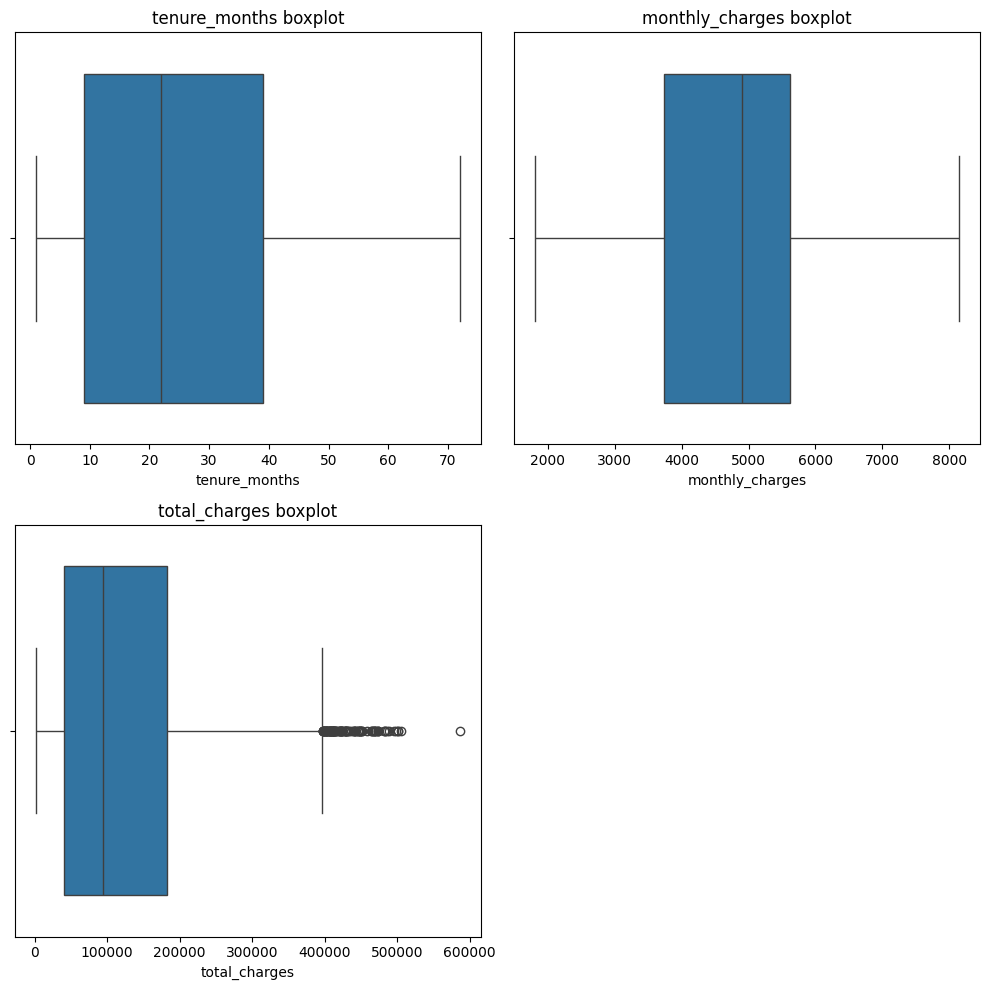

In [67]:
plot_all_boxplots(df_connect)

In [68]:
# Show the outliers in median_house_value Check if they're data errors or genuinely high value customers ie (does monthy_charges * tenure_months = ttotal charges)
# Detecting outliers with IQR for total_charges column
# Define the inter-quartile range
Q1 = df_connect["total_charges"].quantile(0.25)
Q3 = df_connect["total_charges"].quantile(0.75)
IQR = Q3 - Q1

# Determine the lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df_connect [
    (df_connect["total_charges"] < lower_bound) |
    (df_connect["total_charges"] > upper_bound)
]

outliers

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,customer_status
16,CUST00017,Male,No,Yes,No,68,Yes,Yes,DSL,No,Yes,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,6048.94,411327.92,Active
29,CUST00030,Male,No,Yes,No,67,Yes,Yes,Fiber optic,No,Yes,No,Yes,No,No,Month-to-month,Yes,Mailed check,6120.93,410102.31,Active
32,CUST00033,Male,No,No,Yes,63,Yes,Yes,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,6312.24,397671.12,Active
96,CUST00097,Female,Yes,No,No,72,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,No,Bank transfer (automatic),5736.24,413009.28,Active
198,CUST00199,Female,No,Yes,No,58,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,No,Yes,Month-to-month,Yes,Electronic check,6872.01,398576.58,Active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6897,CUST06898,Male,Yes,No,Yes,71,Yes,Yes,DSL,No,No,Yes,Yes,No,Yes,Month-to-month,No,Electronic check,5869.19,416712.49,Active
6901,CUST06902,Male,No,No,No,71,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),6353.51,451099.21,Churned
6930,CUST06931,Male,No,No,No,64,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,6397.98,409470.72,Active
6992,CUST06993,Male,No,Yes,No,61,Yes,Yes,Fiber optic,No,Yes,Yes,No,No,Yes,Month-to-month,Yes,Credit card (automatic),6701.44,408787.84,Active


## Exploratory Data Analysis
### Section Summary


*   The average client has used the service provider for approx. 26 months and incurs monthly charges of USD 4,692. The longest served client has been with the telco for 6 years while the highest paying client pays USD 8,143 per month.
* In general, the clientele is split evenly between the 2 genders, with 16% being senior citizens and 30% being churned



In [69]:
#View Summary Statistics
df_connect.describe()

,tenure_months,monthly_charges,total_charges
count,7043.000000,7043.000000,7043.000000
mean,26.385773,4692.726706,124085.312813
std,20.154208,1262.788244,103725.525082
min,1.000000,1805.910000,1942.930000
25%,9.000000,3737.755000,40014.185000
50%,22.000000,4900.670000,94771.680000
75%,39.000000,5622.675000,182743.935000
max,72.000000,8143.670000,586344.240000


### Who are our customers?


*   The clientele is divided almost equally between the 2 genders (male - 50.9% vs female - 49.1%)
*   15.9% of customers are senior citizens
*   46.7% have partners.
*   29.5% have dependants.



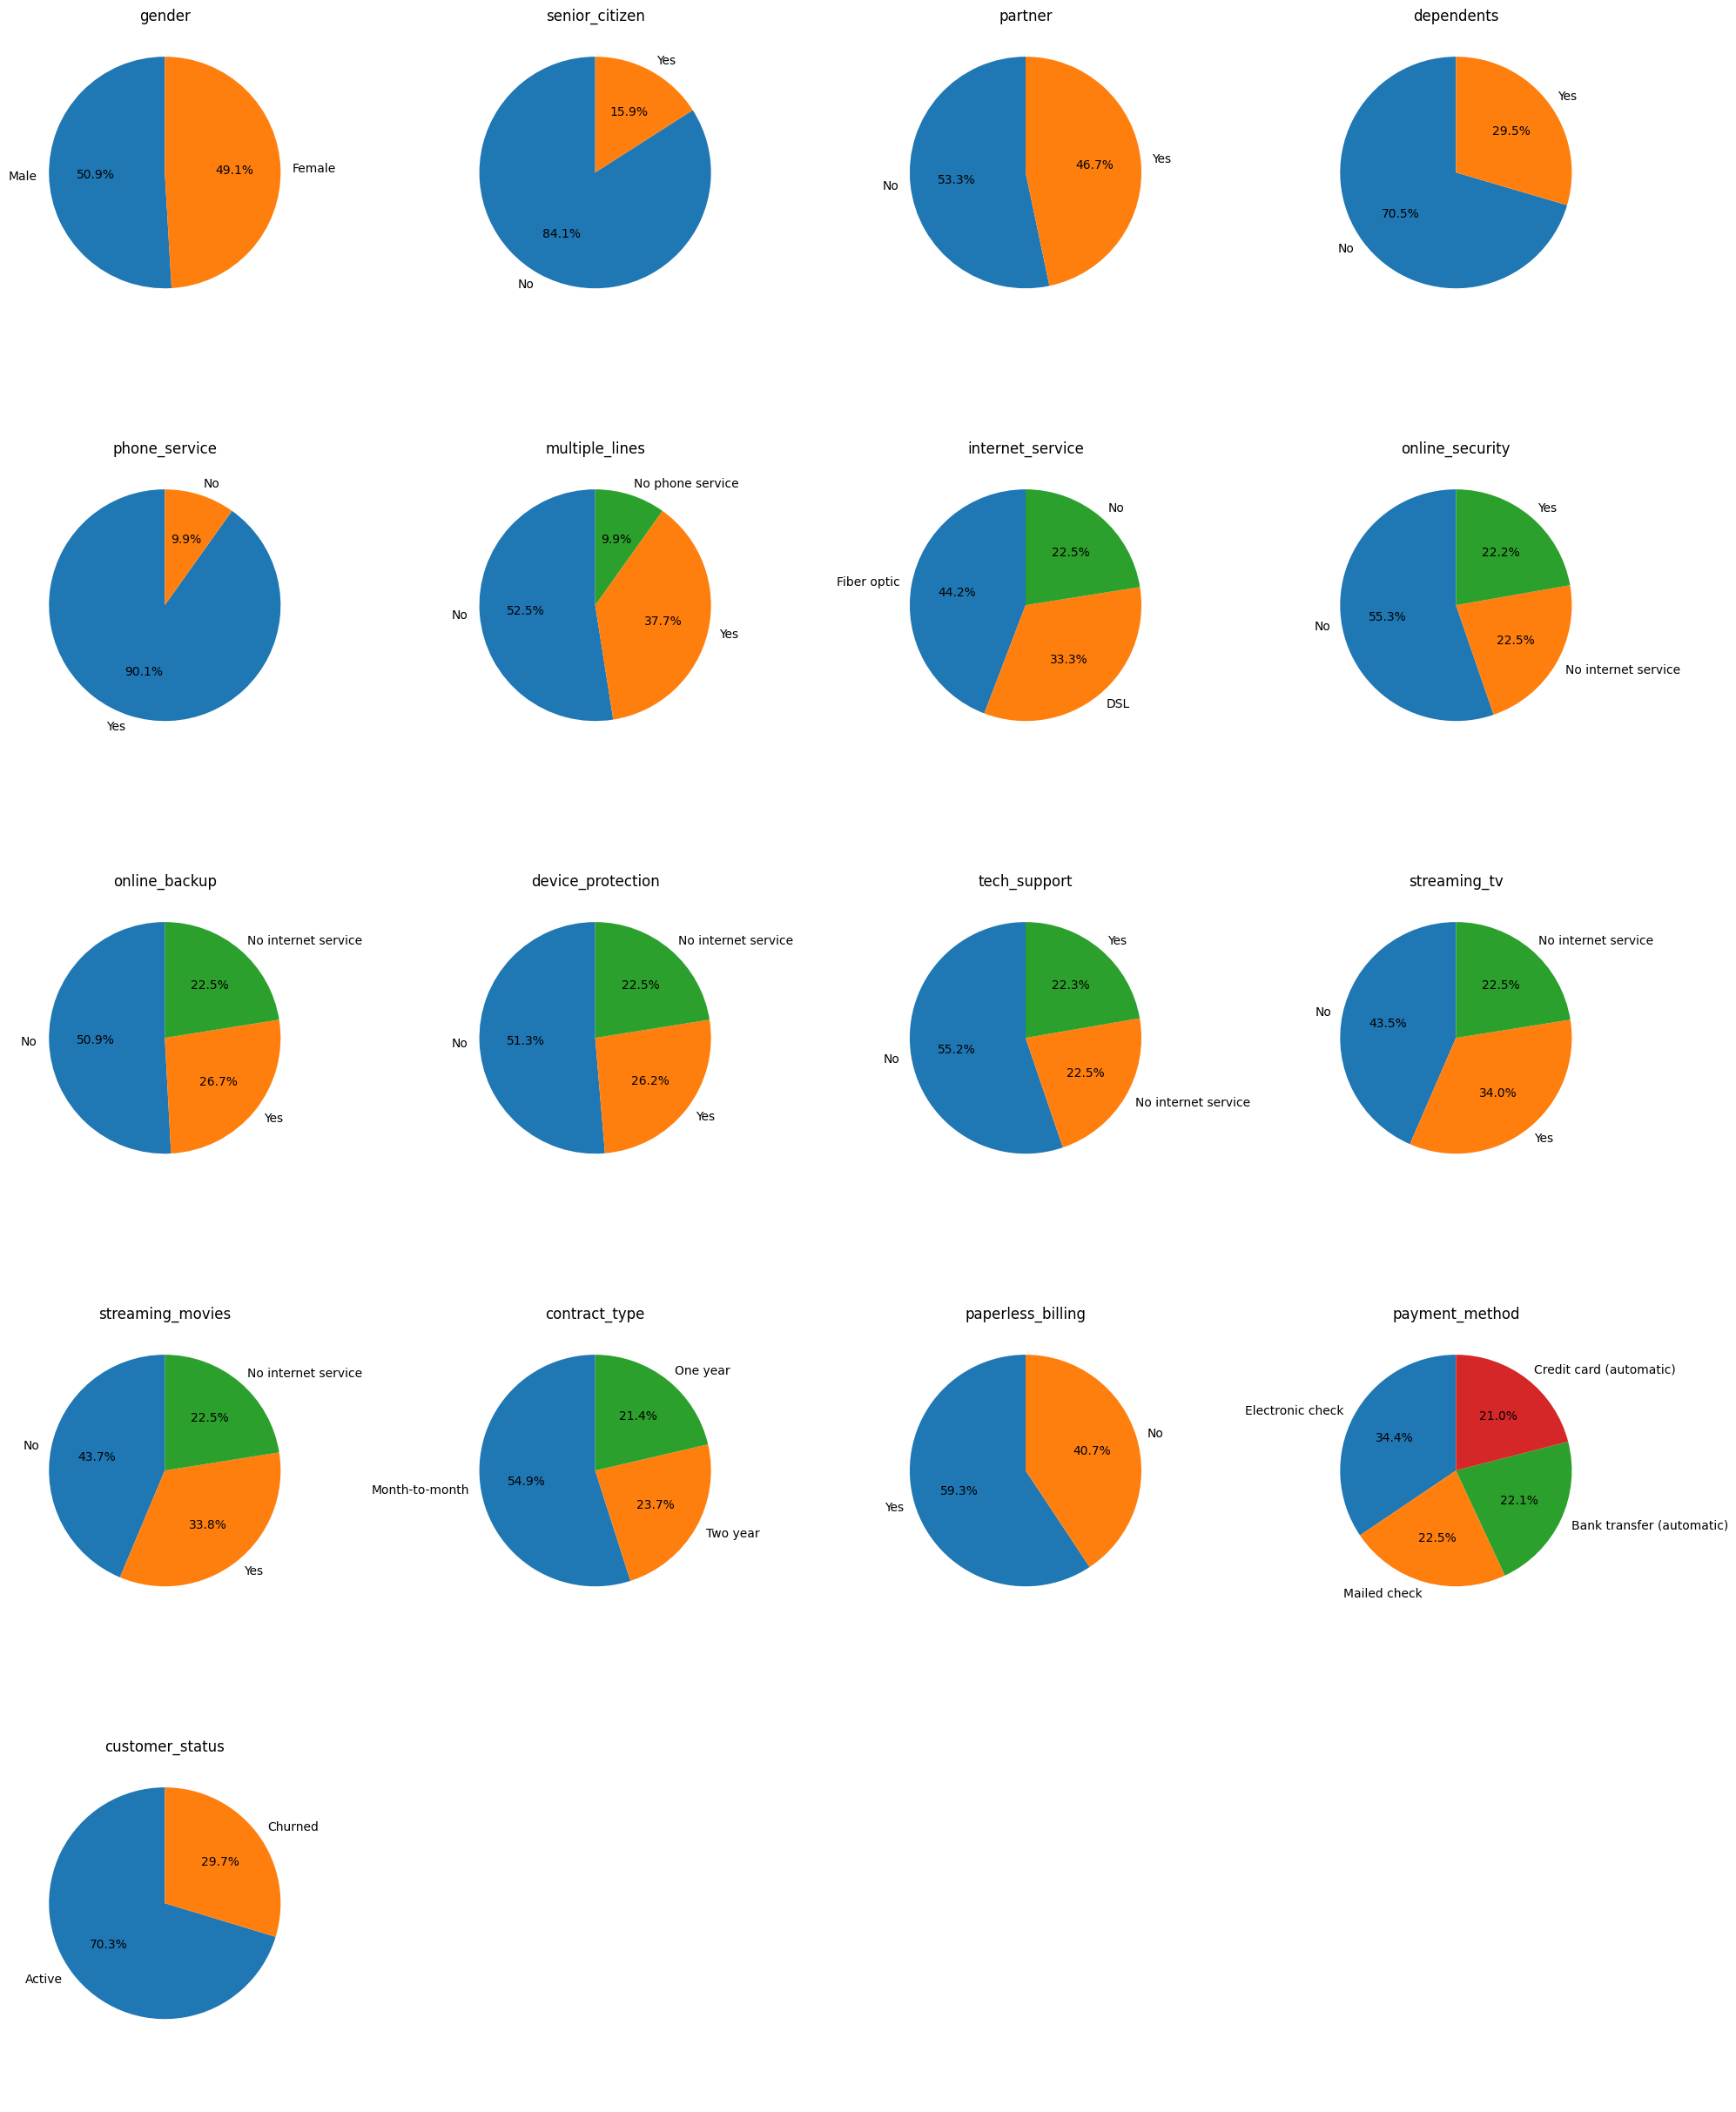

In [70]:
# View Customer Demographics
# Use all columns with dtype 'category'
cat_cols = df_connect.select_dtypes(include=['category']).columns.tolist()

# Number of categorical columns
n_cols = len(cat_cols)

# Define grid layout (e.g., 4 columns per row, adjust as needed)
cols_per_row = 4
rows = math.ceil(n_cols / cols_per_row)

# Create subplots
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, 5*rows))
# Flatten axes array for easy indexing (handles single row/col edge cases)
axes = axes.flatten()

# Loop through each categorical column and plot a pie chart
for i, col in enumerate(cat_cols):
    # Get value counts (dropna=False to include missing values if desired)
    counts = df_connect[col].value_counts(dropna=False)
    # Plot on the i-th subplot
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(col)

# Turn off any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Which services drive loyalty?
The overall churn rate (as shown above) is approx. 30%.
Considering each service the following is evident:


*   Internet services is the biggest driver of custmer loyalty. Having internet dramatically lowers churn (by approx. 23 % points).

*   The table below lists the difference (reduction in churn) in churn rates between customers enjoying the add on service (churn with) and those not enjoying the service (churn without)

| Service | Churn without service | Churn with service | Reduction in churn |
| :--- | :---: | :---: | :---: |
| **Phone service** | 37.0% | 28.9% | **8.1%** |
| **Internet service (DSL)** | 47.3% | 24.6% | **22.7%** |
| **Internet service (Fiber optic)** | 47.3% | 24.5% | **22.8%** |
| **Online security** | 25.3% | 22.7% | **2.6%** |
| **Streaming TV** | 25.5% | 23.4% | **2.1%** |
| **Online backup** | 25.8% | 22.3% | **3.5%** |
| **Device protection** | 26.1% | 21.5% | **4.6%** |
| **Tech support** | 26.5% | 19.8% | **6.7%** |
| **Streaming movies** | 27.0% | 21.5% | **5.5%** |





Churn rate by phone_service:
phone_service
No     0.370
Yes    0.289
Name: churn_flag, dtype: float64


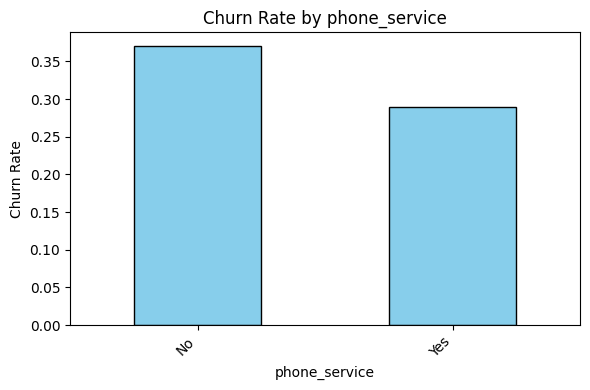


Churn rate by internet_service:
internet_service
DSL            0.246
Fiber optic    0.245
No             0.473
Name: churn_flag, dtype: float64


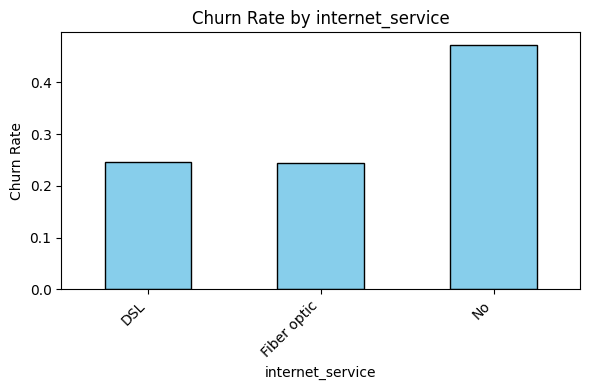


Churn rate by online_security:
online_security
No                     0.253
No internet service    0.473
Yes                    0.227
Name: churn_flag, dtype: float64


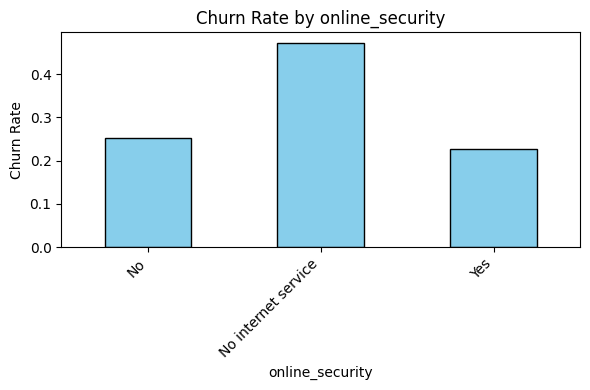


Churn rate by streaming_tv:
streaming_tv
No                     0.255
No internet service    0.473
Yes                    0.234
Name: churn_flag, dtype: float64


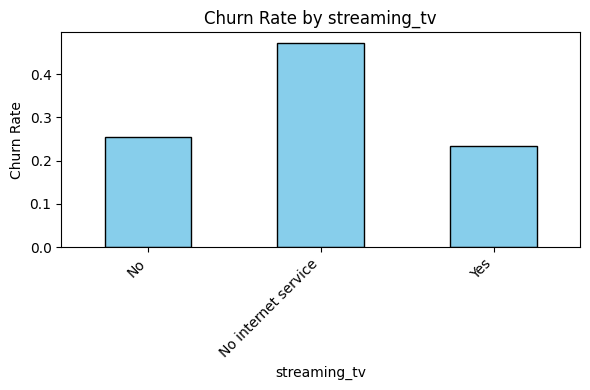


Churn rate by online_backup:
online_backup
No                     0.258
No internet service    0.473
Yes                    0.223
Name: churn_flag, dtype: float64


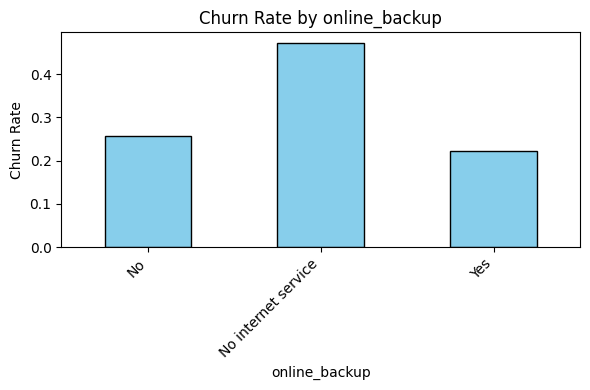


Churn rate by device_protection:
device_protection
No                     0.261
No internet service    0.473
Yes                    0.215
Name: churn_flag, dtype: float64


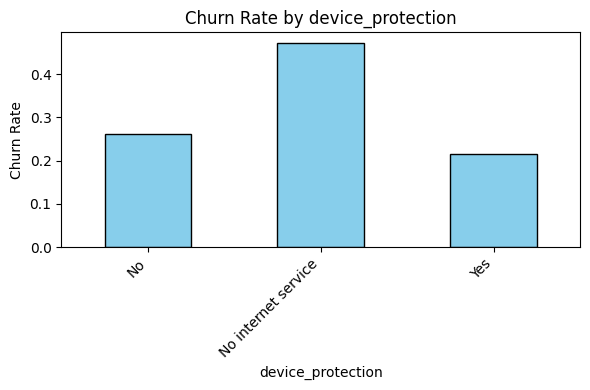


Churn rate by tech_support:
tech_support
No                     0.265
No internet service    0.473
Yes                    0.198
Name: churn_flag, dtype: float64


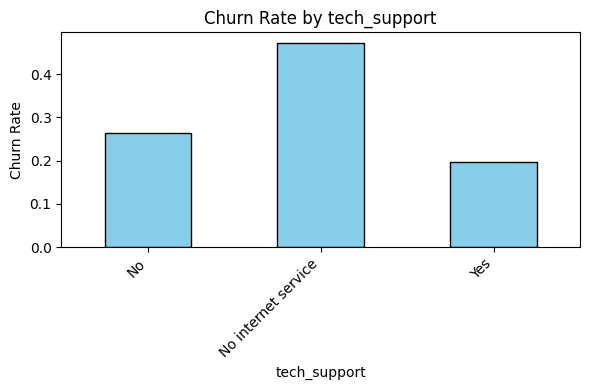


Churn rate by streaming_movies:
streaming_movies
No                     0.270
No internet service    0.473
Yes                    0.215
Name: churn_flag, dtype: float64


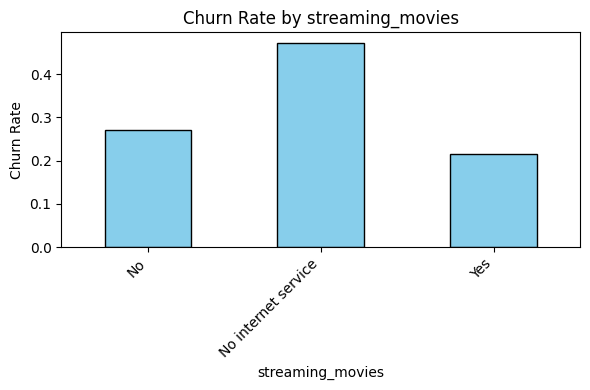

In [71]:
# Convert customer_status to churn flag if not already done
# Ensure churn_flag is defined (if not already)
df_connect['churn_flag'] = (df_connect['customer_status'] == 'Churned').astype(int)

# List of service columns
service_cols = [
    'phone_service', 'internet_service', 'online_security',
    'streaming_tv', 'online_backup', 'device_protection',
    'tech_support', 'streaming_movies'
]

for col in service_cols:
    if col in df_connect.columns:
        # Compute churn rates
        churn_rates = df_connect.groupby(col, observed=True)['churn_flag'].mean().round(3)

        # Print the rates
        print(f"\nChurn rate by {col}:")
        print(churn_rates)

        # Create a bar chart
        plt.figure(figsize=(6, 4))
        churn_rates.plot(kind='bar', color='skyblue', edgecolor='black')
        plt.ylabel('Churn Rate')
        plt.title(f'Churn Rate by {col}')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Column {col} not found.")

### How do contracts and payments affect retention?

### Contracts

*   When considering contracts, the highest dip in customer churn comes from internet services, especially **month - to - month** contracts, where there is a **27 % point drop in churn** (64.5% to 37.7%). The biggest impact comes from getting month - to - month contract customers onto internet services.

*   For phone services, on the other hand, the highest dip in churn was from the **one year contracts**, where there was a **12% point drop**. This means that focusing efforts on phone services customers dramatically helps retain one year contract cusomomers most.

### Payments


*   For every payment method, customers with higher monthly charges have lower church than those with lower monthly charges. Higher monthly charges are associated with greater loyalty.

*   Electronic check users churn at 42.8% (for low charges), this means that targetted retention campaigns should be focusing on  electronic check customers, especially those with lower monthly bills.






In [72]:
#Determine churn rate per service per contract type
service_cols = [
     'phone_service', 'internet_service', 'online_security',
'streaming_tv', 'online_backup', 'device_protection',
'tech_support', 'streaming_movies'
]

for service in service_cols:
    print(f"\n--- {service} ---")
    # Group by contract_type and the service column
    grouped = df_connect.groupby(['contract_type', service], observed=True)['churn_flag'].mean().unstack()
    print(grouped.round(3))


--- phone_service ---
phone_service      No    Yes
contract_type               
Month-to-month  0.505  0.428
One year        0.262  0.142
Two year        0.144  0.098

--- internet_service ---
internet_service    DSL  Fiber optic     No
contract_type                              
Month-to-month    0.378        0.375  0.645
One year          0.117        0.112  0.292
Two year          0.057        0.060  0.253

--- online_security ---
online_security     No  No internet service    Yes
contract_type                                     
Month-to-month   0.387                0.645  0.351
One year         0.120                0.292  0.099
Two year         0.065                0.253  0.041

--- streaming_tv ---
streaming_tv       No  No internet service    Yes
contract_type                                    
Month-to-month  0.385                0.645  0.366
One year        0.137                0.292  0.081
Two year        0.067                0.253  0.048

--- online_backup ---
online_back

charge_category                High       Low
payment_method                               
Bank transfer (automatic)  0.218466  0.337580
Credit card (automatic)    0.194215  0.340426
Electronic check           0.259167  0.428222
Mailed check               0.207981  0.333773


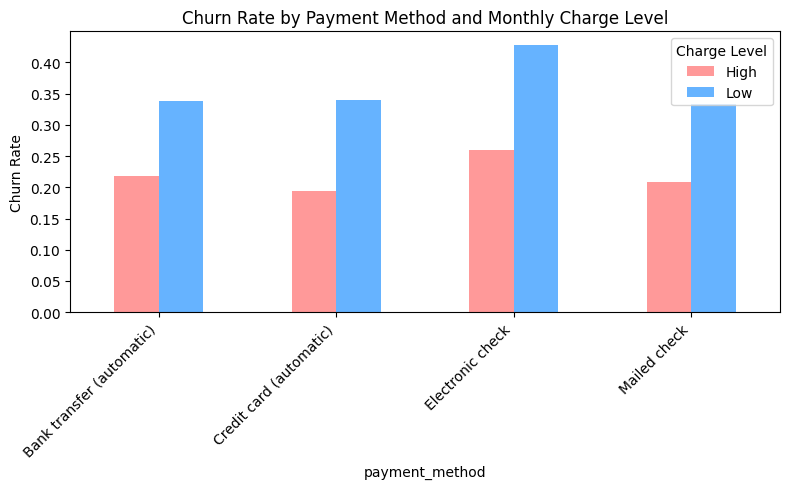

In [73]:
# Churn rate by payment method AND monthly charges (e.g., split at median)
median_charge = df_connect['monthly_charges'].median()
df_connect['charge_category'] = ['Low' if x < median_charge else 'High' for x in df_connect['monthly_charges']]

print(df_connect.groupby(['payment_method', 'charge_category'], observed=True)['churn_flag'].mean().unstack())

pivot = df_connect.groupby(['payment_method', 'charge_category'], observed=True)['churn_flag'].mean().unstack()

# From the cell above, the data is in a DataFrame called 'pivot' with columns 'High', 'Low'


pivot.plot(kind='bar', figsize=(8,5), color=['#ff9999','#66b3ff'])
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Payment Method and Monthly Charge Level')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Charge Level')
plt.tight_layout()
plt.show()

# CONCLUSION AND RECOMMENDATION
## Conclusion


*   There is an even gender split (50%/50%), 16% of whom are senior citizens and 30% have dependants. Average tenure is 26 months and mean monthy charges is 4,692.

*   Customers with  internet churn 23 % points less than those without, regardless of contract type. This makes internet service the strongest loyalty driver.

*   Customer with month - to - month contract types have the highest churn, but they benefit most from internet (27 % point drop). Customers with one - year contracts repond best to phone service (12% point drop).
*   Those who pay with electronic checks, especially those with low monthly charges have the highest churn, at 42.8%.


*   Highest monthly charges correlate with lower churn across all payment methods, iondicating that most high spending clients are loyal.

## Recommendations



1.   Target month-to-month contract customers customers without internet access with special internet access offers (free installation, first month discounts, etc).
2.   Target one-year contract customers with phone service bundles, online backup and streaming TV.
3. Convert customers who pay with electronic checks to other automatic payment methods. Target those with lowest monthly charges first as they are the highest risk.
4. Design loyalty programs that reward increased spending (i.e. discounts on additional services).
5. Impliment win-back campaigns for churned customers. Create incentives that make it easier to hop back onto the service.
6. Train customer service agents to spot high risk clients and proactively offer retention packages.  


